<a href="https://colab.research.google.com/github/sunil965/masai-aiml/blob/master/M5C3_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Link to PDF notes:
https://coding-platform.s3.amazonaws.com/dev/lms/tickets/d96e67f7-5e90-4b45-8e06-fafca4e39640/iwhHGpXWtER3Mmxd.html

# Ensemble Learning: Random Forests
### Hands-on Notebook

**Learning Objectives**
1. Implement **Random Forests** for robust prediction
2. Understand **bootstrap aggregating and feature randomness**

---
An HR team's single decision tree gives noticeably different predictions depending on which employees happen to land in the training set. We'll show that instability directly, then build a Random Forest and show it goes away.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

np.random.seed(15)


## 1. The employee attrition dataset

Four genuinely predictive columns (tenure, satisfaction, overtime, salary standing) plus five columns of pure noise — so we can later check whether the forest handles irrelevant features any differently than a single tree does.


In [ ]:
n = 150
tenure_years = np.random.uniform(0, 15, n)
satisfaction = np.random.uniform(0, 1, n)
monthly_overtime_hours = np.random.uniform(0, 30, n)
salary_percentile = np.random.uniform(0, 1, n)
noise_cols = {f"noise{i}": np.random.uniform(0, 100, n) for i in range(5)}

z = -0.15*tenure_years - 4*satisfaction + 0.08*monthly_overtime_hours - 2*salary_percentile + 1.0
prob_leave = 1 / (1 + np.exp(-z))
left = (np.random.rand(n) < prob_leave).astype(int)

df = pd.DataFrame({
    "tenure_years": tenure_years, "satisfaction": satisfaction,
    "monthly_overtime_hours": monthly_overtime_hours, "salary_percentile": salary_percentile,
    **noise_cols, "left": left,
})
X, y = df.drop(columns="left").values, df["left"].values
feature_names = list(df.drop(columns="left").columns)
print(f"{n} employees, attrition rate: {y.mean():.2f}")


150 employees, attrition rate: 0.21


## 2. Bootstrap sampling, by hand

A bootstrap sample draws the same number of rows as the original data, **with replacement** — some rows appear more than once, others not at all.


In [ ]:
tiny = np.array(["A", "B", "C", "D", "E", "F"])
np.random.seed(2)
bootstrap_sample = np.random.choice(tiny, size=len(tiny), replace=True)
print("Bootstrap sample:", list(bootstrap_sample))
print("Never selected:  ", sorted(set(tiny) - set(bootstrap_sample)))


Bootstrap sample: [np.str_('A'), np.str_('F'), np.str_('A'), np.str_('D'), np.str_('C'), np.str_('D')]
Never selected:   [np.str_('B'), np.str_('E')]


**Checkpoint:** this should match the slide — sample `[A, F, A, D, C, D]`, with B and E never selected. Every tree in a Random Forest gets its own draw like this from the real training data.


## 3. Comparing stability: one tree vs. a forest, across six splits

Same data, same six train/test splits — the only thing that changes is which model we fit.


In [ ]:
def accuracy_across_splits(model_fn, X, y, n_splits=6, test_size=0.3):
    accs = []
    for rs in range(n_splits):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rs)
        model = model_fn()
        model.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, model.predict(X_test)))
    return np.array(accs)

tree_accs = accuracy_across_splits(lambda: DecisionTreeClassifier(random_state=42), X, y)
rf_accs = accuracy_across_splits(lambda: RandomForestClassifier(n_estimators=100, random_state=42), X, y)

print("Single tree:   ", [round(a, 3) for a in tree_accs], f"mean={tree_accs.mean():.3f}  range={tree_accs.max()-tree_accs.min():.3f}")
print("Random Forest: ", [round(a, 3) for a in rf_accs], f"mean={rf_accs.mean():.3f}  range={rf_accs.max()-rf_accs.min():.3f}")


Single tree:    [np.float64(0.622), np.float64(0.644), np.float64(0.889), np.float64(0.756), np.float64(0.756), np.float64(0.644)] mean=0.719  range=0.267
Random Forest:  [np.float64(0.8), np.float64(0.822), np.float64(0.844), np.float64(0.778), np.float64(0.889), np.float64(0.778)] mean=0.819  range=0.111


**Checkpoint:** this should match the slide — single tree mean ≈ 0.719, range ≈ 0.267; Random Forest mean ≈ 0.819, range ≈ 0.111.


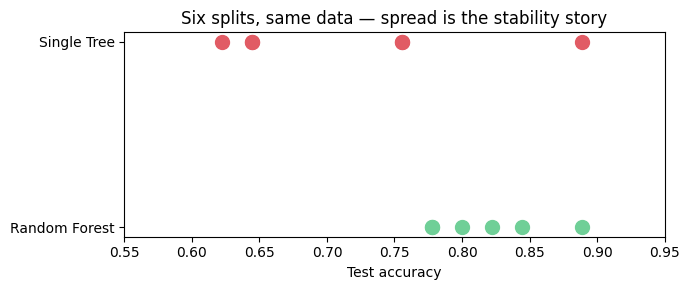

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(tree_accs, [1]*len(tree_accs), s=100, color="#E15B64", label="Single Tree", zorder=3)
ax.scatter(rf_accs, [0]*len(rf_accs), s=100, color="#6FCF97", label="Random Forest", zorder=3)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Random Forest", "Single Tree"])
ax.set_xlabel("Test accuracy")
ax.set_title("Six splits, same data — spread is the stability story")
ax.set_xlim(0.55, 0.95)
plt.tight_layout(); plt.show()


## 4. What feature randomness changes

Look at how each model's `feature_importances_` are distributed across the 4 real features and the 5 noise features, on one fixed split.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

importance_df = pd.DataFrame({
    "SingleTree": tree.feature_importances_,
    "RandomForest": rf.feature_importances_,
}, index=feature_names).round(3)
importance_df


,SingleTree,RandomForest
tenure_years,0.136,0.147
satisfaction,0.288,0.216
monthly_overtime_hours,0.242,0.152
salary_percentile,0.000,0.072
noise0,0.065,0.111
noise1,0.094,0.088
noise2,0.020,0.075
noise3,0.000,0.080
noise4,0.155,0.058


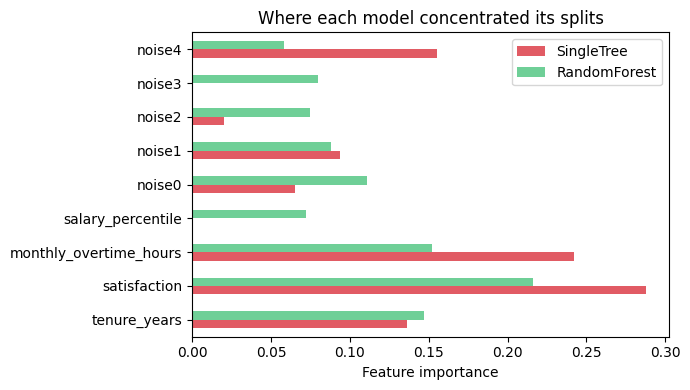

Single tree - real feature total: 0.666
Random Forest - real feature total: 0.587


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
importance_df.plot(kind="barh", ax=ax, color=["#E15B64", "#6FCF97"])
ax.set_xlabel("Feature importance")
ax.set_title("Where each model concentrated its splits")
plt.tight_layout(); plt.show()

real_features = ["tenure_years", "satisfaction", "monthly_overtime_hours", "salary_percentile"]
print("Single tree - real feature total:", round(importance_df.loc[real_features, "SingleTree"].sum(), 3))
print("Random Forest - real feature total:", round(importance_df.loc[real_features, "RandomForest"].sum(), 3))


Notice `salary_percentile` gets **zero** importance in the single tree — once the tree picks its splits, it never happens to use that column at all. In the forest, feature randomness forces different trees to consider it when the strongest features aren't available as candidates, so it ends up with real, non-zero importance instead of being silently ignored.


## 5. Exercises


**Exercise 1.** Refit a Random Forest with `n_estimators=10` instead of 100, and run it through `accuracy_across_splits`. Does the range grow or shrink compared to `n_estimators=100`?


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
rf_small_accs = accuracy_across_splits(lambda: RandomForestClassifier(n_estimators=10, random_state=42), X, y)
print([round(a, 3) for a in rf_small_accs], rf_small_accs.max() - rf_small_accs.min())
```
On this dataset, 10 trees actually gives a *narrower* range (≈0.067) than 100 trees (≈0.111) — a reminder that "more trees = more stable" is a tendency across many datasets and runs, not a guarantee on any single one. What 10 trees reliably loses is headroom: with fewer independent votes, each individual tree's bootstrap luck matters more, so results are less *reproducible* if you changed the random seed, even when this particular range happens to look fine.
</details>


**Exercise 2.** Using `importance_df`, write one line to find which single feature the Random Forest considers most important.


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
print(importance_df["RandomForest"].idxmax())
# satisfaction
```
</details>


**Exercise 3.** Compute the mean test accuracy of a Random Forest with `max_features=None` (i.e., every split considers *all* features, turning off feature randomness — only bootstrap sampling remains) across the same 6 splits. Compare it to the default forest's mean.


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
rf_no_feat_rand = accuracy_across_splits(
    lambda: RandomForestClassifier(n_estimators=100, max_features=None, random_state=42), X, y
)
print(rf_no_feat_rand.mean(), rf_no_feat_rand.std())
```
On this dataset, turning off feature randomness (mean ≈ 0.83, std ≈ 0.031) actually does slightly *better* than the default forest (mean ≈ 0.819) — feature randomness is not free variance reduction on every dataset, it's a bias-variance trade-off of its own. It tends to help most specifically when a few features would otherwise dominate every tree's early splits (as seen with `satisfaction` in Section 4); with only 4 real signal columns here, bootstrap sampling alone was already diversifying the trees reasonably well.
</details>


## 6. Recap

- **Bootstrap aggregating (bagging)**: each tree in the forest trains on its own random resample of the data (with replacement), and the forest's prediction is a vote (or average) across all trees.
- **Feature randomness**: each split considers only a random subset of features, stopping every tree from converging on the same dominant-feature structure.
- Together, these make each tree genuinely different — and averaging genuinely different, individually-imperfect trees is what makes the forest both **more accurate** and **far more stable** than any single tree.
